# Active Learning Simulation for Lycopene Production Using Hybrid Active Learning (HAL)

This notebook simulates an active learning cycle using initial experimental data (Round 0) to train an XGBoost model. It explores the experimental condition space using `HAL`.
recommendation algorithms iteratively from Round 1 to Round 5.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yoonbang98/Hybrid-active-learning-framework/blob/main/HAL_example_Lycopene.ipynb)

In [ ]:
!git clone https://github.com/yoonbang98/Hybrid-active-learning-framework.git

import os
os.chdir('/content/Hybrid-active-learning-framework')

!pip install statannotation

In [1]:
import os
import numpy as np
import pandas as pd
import json
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statannotations.Annotator import Annotator

# Import custom recommendation algorithms and preprocessing functions
from Recommendation_function import preprocess, make_onehot, optimize_param, transform_df, test_func,\
    generate_all_possible_conditions, METIS_recommendation, HAL_recommendation

import matplotlib
import matplotlib.pyplot  as plt
import seaborn as sns
import shap
%matplotlib inline

## Step 1. Initial Data (Round 0) Import and Preprocessing
Load the initial training data (Round 0) and the random test set. Categorical variables are transformed using one-hot encoding so that the machine learning model can process them appropriately.

In [2]:
path = os.getcwd()
lycopene_data = pd.read_csv(path + '/data/Lycopene/exp_data/Day0_train_x.csv')
label = pd.read_csv(path + '/data/Lycopene/exp_data/Day0_train_y.csv')['0']

col_list = ['Idi','Idi_conc','ispA','ispA_conc','CrtE','CrtE_conc','CrtB','CrtB_conc','CrtI','CrtI_conc']
col_list_total = ['SlIdi', 'AtIdi', 'RcIdi', 'OgIdi',
                   'EcispA', 'KaispA', 'JcispA', 'SeispA', 'BaispA',
                   'PacrtE', 'KpcrtE', 'HpcrtE', 'NicrtE', 'ShcrtE',
                   'PacrtB', 'KpcrtB', 'LacrtB', 'RccrtB', 'SicrtB',
                   'PacrtI', 'ErcrtI', 'SscrtI', 'BvcrtI', 'LacrtI',
                 'Idi_conc', 'ispA_conc', 'CrtE_conc', 'CrtB_conc', 'CrtI_conc']

In [3]:
lycopene_processed_onehot = lycopene_data
lycopene_processed_onehot

,SlIdi,AtIdi,RcIdi,OgIdi,EcispA,KaispA,JcispA,SeispA,BaispA,PacrtE,...,PacrtI,ErcrtI,SscrtI,BvcrtI,LacrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,1,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0.25,0.25,0.10,0.25,0.25
1,1,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0.25,1.00,0.25,0.25,0.25
2,1,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0.25,0.25,0.25,0.25,0.25
3,1,0,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0.25,0.25,0.25,0.25,0.50
4,1,0,0,0,1,0,0,0,0,1,...,1,0,0,0,0,0.25,0.25,0.25,0.10,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,1,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0.25,0.25,1.00,0.25,0.25
73,1,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0.25,0.10,0.25,0.25,0.25
74,1,0,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0.25,0.25,0.25,0.25,0.25
75,0,0,1,0,1,0,0,0,0,1,...,1,0,0,0,0,1.00,0.25,0.25,0.25,0.25


In [4]:
random_test = pd.read_csv(path + '/data/Lycopene/random_test_set_result.csv')
random_label = random_test['result'].apply(lambda x: max(0, x))
random_test.drop(columns = ['result'], inplace = True)
random_test_processed, random_label_processed = preprocess(random_test, random_label, col_list)
random_test_processed_onehot = make_onehot(random_test_processed)

In [5]:
random_test_processed_onehot

,SlIdi,AtIdi,RcIdi,OgIdi,EcispA,KaispA,JcispA,SeispA,BaispA,PacrtE,...,PacrtI,ErcrtI,SscrtI,BvcrtI,LacrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0.10,0.50,0.50,0.25,0.25
1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0.10,0.10,0.50,0.25,0.50
2,0,1,0,0,0,0,0,0,1,1,...,0,0,1,0,0,0.10,0.25,1.00,0.25,0.10
3,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0.10,1.00,0.50,0.10,0.25
4,0,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0.25,0.10,0.25,0.50,0.10
5,0,1,0,0,1,0,0,0,0,1,...,0,0,0,1,0,0.25,0.25,0.50,0.25,0.25
6,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0.25,1.00,1.00,0.50,0.25
7,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0.25,0.25,1.00,0.50,0.50
8,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0.50,1.00,0.25,0.50,0.50
9,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0.50,1.00,0.25,0.25,1.00


### Search Space Generation and Scaling
Generate all possible experimental conditions to find the optimal recommendations. Then, apply `MinMaxScaler` to normalize the features between 0 and 1.

In [6]:
ALL_possible_conditions = generate_all_possible_conditions()

scaler = MinMaxScaler()
scaled_ALL_possible_conditions = scaler.fit_transform(ALL_possible_conditions)
scaled_X_train = scaler.transform(lycopene_processed_onehot)
scaled_X_test = scaler.transform(random_test_processed_onehot)

3200000it [00:26, 121353.97it/s]


Number of all possible experimental conditions : 2688000


## Step 2 ~ 4. Iterative Recommendation Process (Round 1 ~ Round 5)
Simulate the active learning cycle:  
  
#### Step 2 (Round N tuning) : Optimize the model hyperparameters (`optimize_param`) and evaluate the performance.
#### Step 3 (Round N Recommendation): Recommend 10 optimal conditions for the next round using the `HAL` algorithm.
#### Step 4 (Round N Update) : In Vitro execution and concatenate the new experimental results with the existing training data.

### Round 1

#### Round 1 tuning

In [7]:
y_train = label
params_list, grid_results = optimize_param(scaled_X_train, y_train)

0.22929031432349817


In [8]:
# load param data
with open(path + '/data/Lycopene/exp_param/day0_param.json', 'r') as f:
    params_list = json.load(f)

In [9]:
day0_mae, day0_r2, day0_pred = test_func(params_list, scaled_X_train, scaled_X_test, y_train, random_label_processed)

Test score MAE: 0.438018758099562
Test score R2: 0.2637702178268351


#### Round 1 Recommendation

#### This cell is for recommending experimental conditions. Since the next conditions are already saved, you can skip executing this cell and proceed directly to the Round Update.

In [ ]:
sampling_num = 10 # Sample 10 next experimental conditions using the HAL algorithm
round_num = 5
day = 1
HAL_next = HAL_recommendation(params_list, scaled_X_train, y_train, scaled_ALL_possible_conditions, day, sampling_num, round_num)

In [ ]:
HAL_next_df = pd.DataFrame(scaler.inverse_transform(HAL_next), columns = col_list_total)
HAL_next_df_transformed = transform_df(HAL_next_df)

In [169]:
HAL_next_df_transformed 

,Idi,ispA,CrtE,CrtB,CrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,2,5,5,5,3,1.00,1.0,1.0,1.0,1.0
1,4,4,3,2,4,1.00,1.0,0.1,1.0,1.0
2,3,3,2,3,5,1.00,1.0,1.0,1.0,1.0
3,4,2,4,4,2,1.00,1.0,1.0,0.1,1.0
4,3,3,3,4,2,1.00,0.1,0.1,1.0,0.1
5,2,2,2,4,3,0.10,1.0,0.1,1.0,0.1
6,2,4,2,2,2,0.10,1.0,1.0,0.1,1.0
7,4,3,5,3,3,0.10,1.0,1.0,0.1,0.1
8,2,3,4,5,5,0.10,1.0,0.1,0.1,1.0
9,4,5,3,3,5,0.25,0.1,0.1,1.0,0.1


In [170]:
HAL_next_df_transformed.iloc[:, :5].value_counts() #ECispA, SiIDI, LpcrtE, LpcrtB, LacrtI

Idi  ispA  CrtE  CrtB  CrtI
2    2     2     4     3       1
     3     4     5     5       1
     4     2     2     2       1
     5     5     5     3       1
3    3     2     3     5       1
           3     4     2       1
4    2     4     4     2       1
     3     5     3     3       1
     4     3     2     4       1
     5     3     3     5       1
Name: count, dtype: int64

#### Round 1 Update

In [10]:
# load data
with open('/work/home/ybchae/active_learning/data/lycopene/param/day0_param.json', 'r') as f:
    params_list = json.load(f)

In [11]:
HAL_day1 = pd.read_csv(path + '/data/Lycopene/exp_result/HAL_Day1_result.csv') # Load Round 1 experimental results and merge them with Day 0 training data

HAL_day1_label = HAL_day1['result'].apply(lambda x: max(0, x))
HAL_day1.drop(columns = ['result'], inplace = True)

col_list = HAL_day1.columns.tolist()

HAL_day1_processed, HAL_day1_label_processed = preprocess(HAL_day1, HAL_day1_label, col_list)
HAL_day1_processed_onehot = make_onehot(HAL_day1_processed)

day0_X_train = pd.read_csv(path + '/data/Lycopene/exp_data/Day0_train_x.csv')
day0_y_train = pd.read_csv(path + '/data/Lycopene/exp_data/Day0_train_y.csv')

HAL_day1_X_train = pd.concat([day0_X_train, HAL_day1_processed_onehot], axis = 0).reset_index(drop = True)
HAL_day1_y_train = pd.concat([day0_y_train['0'], HAL_day1_label_processed], axis = 0).reset_index(drop = True)

scaled_HAL_day1_X_train = scaler.transform(HAL_day1_X_train)
scaled_HAL_day1_X_train.shape

(87, 29)

### Round 2

#### Round 2 tuning

In [12]:
HAL_day1_params_list, HAL_day1_grid_results = optimize_param(scaled_HAL_day1_X_train, HAL_day1_y_train) 

0.2191170933649734


In [13]:
HAL_day1_mae, HAL_day1_r2, HAL_day1_pred = test_func(HAL_day1_params_list, scaled_HAL_day1_X_train, scaled_X_test, HAL_day1_y_train, random_label_processed)

Test score MAE: 0.3694257881037781
Test score R2: 0.49443457213669517


#### Round 2 recommendation

#### This cell is for recommending experimental conditions. Since the next conditions are already saved, you can skip executing this cell and proceed directly to the Round Update.

In [ ]:
sampling_num = 10
round_num = 5
day = 2
HAL_day2_recommend = HAL_recommendation(HAL_day1_params_list, scaled_HAL_day1_X_train, HAL_day1_y_train, scaled_ALL_possible_conditions, day, sampling_num, round_num)

In [ ]:
HAL_day2_recommend_df = pd.DataFrame(scaler.inverse_transform(HAL_day2_recommend), columns = col_list_total)
HAL_day2_recommend_transformed = transform_df(HAL_day2_recommend_df)

In [85]:
HAL_day2_recommend_transformed

,Idi,ispA,CrtE,CrtB,CrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,3,2,3,5,4,0.10,1.00,1.00,0.1,1.0
1,2,4,4,3,4,0.50,0.25,1.00,1.0,0.1
2,1,4,3,3,3,1.00,1.00,1.00,0.1,1.0
3,3,5,5,2,4,1.00,0.10,1.00,0.1,0.1
4,2,2,3,2,5,1.00,0.50,1.00,0.5,0.1
5,3,4,4,4,3,0.25,0.10,0.25,1.0,1.0
6,4,4,3,5,2,0.10,0.25,1.00,0.1,0.1
7,1,5,3,2,2,0.10,1.00,1.00,1.0,0.1
8,2,5,3,4,4,0.25,0.10,0.10,0.1,1.0
9,4,2,4,2,3,0.10,0.25,0.10,0.1,0.1


In [105]:
HAL_day2_recommend_transformed.iloc[:, :5].value_counts()

Idi  ispA  CrtE  CrtB  CrtI
1    4     3     3     3       1
     5     3     2     2       1
2    2     3     2     5       1
     4     4     3     4       1
     5     3     4     4       1
3    2     3     5     4       1
     4     4     4     3       1
     5     5     2     4       1
4    2     4     2     3       1
     4     3     5     2       1
Name: count, dtype: int64

#### Round 2 Update

In [14]:
# load data
with open(path + '/data/Lycopene/exp_param/day1_HAL_param.json', 'r') as f:
    day1_HAL_params_list = json.load(f)

In [15]:
HAL_day2 = pd.read_csv(path + '/data/Lycopene/exp_result/HAL_Day2_result.csv')

HAL_day2_label = HAL_day2['result'].apply(lambda x: max(0, x))
HAL_day2.drop(columns = ['result'], inplace = True)

col_list = HAL_day2.columns.tolist()

HAL_day2_processed, HAL_day2_label_processed = preprocess(HAL_day2, HAL_day2_label, col_list)
HAL_day2_processed_onehot = make_onehot(HAL_day2_processed)

HAL_day1_X_train = pd.read_csv(path + '/data/Lycopene/exp_data/HAL_Day1_train_x.csv')
HAL_day1_y_train = pd.read_csv(path + '/data/Lycopene/exp_data/HAL_Day1_train_y.csv')

HAL_day2_X_train = pd.concat([HAL_day1_X_train, HAL_day2_processed_onehot], axis = 0).reset_index(drop = True)
HAL_day2_y_train = pd.concat([HAL_day1_y_train['0'], HAL_day2_label_processed], axis = 0).reset_index(drop = True)

scaled_HAL_day2_X_train = scaler.transform(HAL_day2_X_train)
scaled_HAL_day2_X_train.shape

(97, 29)

### Round 3

#### Round 3 tuning

In [16]:
HAL_day2_params_list, HAL_day2_grid_results = optimize_param(scaled_HAL_day2_X_train, HAL_day2_y_train)

0.2857664194231483


In [17]:
HAL_day2_mae, HAL_day2_r2, HAL_day2_pred = test_func(HAL_day2_params_list, scaled_HAL_day2_X_train, scaled_X_test, HAL_day2_y_train, random_label_processed)

Test score MAE: 0.2819171238980028
Test score R2: 0.7034779902469166


#### Round 3 recommendation

#### This cell is for recommending experimental conditions. Since the next conditions are already saved, you can skip executing this cell and proceed directly to the Round Update.

In [ ]:
sampling_num = 10
round_num = 5
day = 3
HAL_day3_recommend = HAL_recommendation(HAL_day2_params_list, scaled_HAL_day2_X_train, HAL_day2_y_train, scaled_ALL_possible_conditions, day, sampling_num, round_num)

In [ ]:
HAL_day3_recommend_df = pd.DataFrame(scaler.inverse_transform(HAL_day3_recommend), columns = col_list_total)
HAL_day3_recommend_transformed = transform_df(HAL_day3_recommend_df)

In [477]:
HAL_day3_recommend_transformed

,Idi,ispA,CrtE,CrtB,CrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,3,1,3,2,3,0.25,1.00,0.1,0.50,0.50
1,4,2,1,3,3,1.00,0.10,1.0,1.00,1.00
2,3,5,1,4,5,0.25,0.10,1.0,1.00,0.10
3,4,3,1,2,5,0.10,0.10,1.0,0.10,0.10
4,2,5,1,3,2,0.10,1.00,1.0,0.25,0.25
5,4,1,3,5,5,1.00,1.00,0.1,0.25,1.00
6,3,2,1,4,3,1.00,1.00,1.0,0.10,0.10
7,3,5,4,5,4,0.10,0.50,0.1,1.00,0.10
8,3,4,5,5,5,1.00,0.25,0.1,0.50,0.10
9,2,3,1,5,3,1.00,0.25,1.0,0.10,0.10


In [190]:
HAL_day3_recommend_transformed.iloc[:, :5].value_counts()

Idi  ispA  CrtE  CrtB  CrtI
0    3     1     4     2       1
2    5     1     3     2       1
3    1     3     2     3       1
     2     1     4     3       1
     4     5     5     5       1
     5     1     4     5       1
           4     5     4       1
4    1     3     5     5       1
     2     1     3     3       1
     3     1     2     5       1
Name: count, dtype: int64

#### Round 3 Update

In [18]:
#load param data
with open(path + '/data/Lycopene/exp_param/day2_HAL_param.json', 'r') as f:
    day2_HAL_params_list = json.load(f)

In [19]:
HAL_day3 = pd.read_csv(path + '/data/Lycopene/exp_result/HAL_Day3_result.csv')

HAL_day3_label = HAL_day3['result'].apply(lambda x: max(0, x))
HAL_day3.drop(columns = ['result'], inplace = True)

col_list = HAL_day3.columns.tolist()

HAL_day3_processed, HAL_day3_label_processed = preprocess(HAL_day3, HAL_day3_label, col_list)
HAL_day3_processed_onehot = make_onehot(HAL_day3_processed)

HAL_day2_X_train = pd.read_csv(path + '/data/Lycopene/exp_data/HAL_Day2_train_x.csv')
HAL_day2_y_train = pd.read_csv(path + '/data/Lycopene/exp_data/HAL_Day2_train_y.csv')

HAL_day3_X_train = pd.concat([HAL_day2_X_train, HAL_day3_processed_onehot], axis = 0).reset_index(drop = True)
HAL_day3_y_train = pd.concat([HAL_day2_y_train['0'], HAL_day3_label_processed], axis = 0).reset_index(drop = True)

scaled_HAL_day3_X_train = scaler.transform(HAL_day3_X_train)
scaled_HAL_day3_X_train.shape

(107, 29)

### Round 4

#### Round 4 tuning

In [20]:
HAL_day3_params_list, HAL_day3_grid_results = optimize_param(scaled_HAL_day3_X_train, HAL_day3_y_train)

0.30498210891398775


In [21]:
HAL_day3_mae, HAL_day3_r2, HAL_day3_pred = test_func(HAL_day3_params_list, scaled_HAL_day3_X_train, scaled_X_test, HAL_day3_y_train, random_label_processed)

Test score MAE: 0.2747844463499893
Test score R2: 0.6695731057160974


#### Round 4 recommendation

#### This cell is for recommending experimental conditions. Since the next conditions are already saved, you can skip executing this cell and proceed directly to the Round Update.

In [ ]:
sampling_num = 10
round_num = 5
day = 4
HAL_day4_recommend = HAL_recommendation(HAL_day3_params_list, scaled_HAL_day3_X_train, HAL_day3_y_train, scaled_ALL_possible_conditions, day, sampling_num, round_num)

In [ ]:
HAL_day4_recommend_df = pd.DataFrame(scaler.inverse_transform(HAL_day4_recommend), columns = col_list_total)
HAL_day4_recommend_transformed = transform_df(HAL_day4_recommend_df)

In [669]:
HAL_day4_recommend_transformed

,Idi,ispA,CrtE,CrtB,CrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,4,3,3,1,4,0.25,1.00,0.10,0.25,0.1
1,3,5,3,1,5,0.10,1.00,0.10,0.25,1.0
2,1,3,4,2,3,1.00,1.00,1.00,1.00,0.5
3,1,4,3,1,5,1.00,1.00,0.10,1.00,0.1
4,2,1,3,3,2,0.50,0.25,0.10,1.00,1.0
5,1,4,1,4,2,1.00,0.10,1.00,1.00,1.0
6,1,2,3,4,5,0.25,0.10,0.10,0.25,0.1
7,1,2,3,1,4,1.00,1.00,0.10,0.50,1.0
8,3,1,4,1,4,1.00,1.00,0.10,1.00,1.0
9,2,2,4,3,1,0.10,0.25,0.25,0.25,1.0


#### Round 4 Update

In [22]:
# load param data
with open(path + '/data/Lycopene/exp_param/day3_HAL_param.json', 'r') as f:
    day3_HAL_params_list = json.load(f)

In [23]:
HAL_day4 = pd.read_csv(path + '/data/Lycopene/exp_result/HAL_Day4_result.csv')

HAL_day4_label = HAL_day4['result'].apply(lambda x: max(0, x))
HAL_day4.drop(columns = ['result'], inplace = True)

col_list = HAL_day4.columns.tolist()

HAL_day4_processed, HAL_day4_label_processed = preprocess(HAL_day4, HAL_day4_label, col_list)
HAL_day4_processed_onehot = make_onehot(HAL_day4_processed)

HAL_day3_X_train = pd.read_csv('/work/home/ybchae/active_learning/data/lycopene/HAL_Day3_train_x.csv')
HAL_day3_y_train = pd.read_csv('/work/home/ybchae/active_learning/data/lycopene/HAL_Day3_train_y.csv')

HAL_day4_X_train = pd.concat([HAL_day3_X_train, HAL_day4_processed_onehot], axis = 0).reset_index(drop = True)
HAL_day4_y_train = pd.concat([HAL_day3_y_train['0'], HAL_day4_label_processed], axis = 0).reset_index(drop = True)

scaled_HAL_day4_X_train = scaler.transform(HAL_day4_X_train)
scaled_HAL_day4_X_train.shape

(117, 29)

### Round 5

#### Round 5 tuning

In [24]:
HAL_day4_params_list, HAL_day4_grid_results = optimize_param(HAL_day4_X_train, HAL_day4_y_train)

0.32053587547448326


In [25]:
HAL_day4_mae, HAL_day4_r2, HAL_day4_pred = test_func(HAL_day4_params_list, scaled_HAL_day4_X_train, scaled_X_test, HAL_day4_y_train, random_label_processed)

Test score MAE: 0.2647237479664708
Test score R2: 0.6851310571696456


#### Round 5 Recommendation

#### This cell is for recommending experimental conditions. Since the next conditions are already saved, you can skip executing this cell and proceed directly to the Round Update.

In [ ]:
sampling_num = 10
round_num = 5
day = 5
HAL_day5_recommend = HAL_recommendation(HAL_day4_params_list, scaled_HAL_day4_X_train, HAL_day4_y_train, scaled_ALL_possible_conditions, day, sampling_num, round_num)

In [ ]:
HAL_day5_recommend_df = pd.DataFrame(scaler.inverse_transform(HAL_day5_recommend), columns = col_list_total)
HAL_day5_recommend_transformed = transform_df(HAL_day5_recommend_df)

In [149]:
HAL_day5_recommend_transformed

,Idi,ispA,CrtE,CrtB,CrtI,Idi_conc,ispA_conc,CrtE_conc,CrtB_conc,CrtI_conc
0,1,4,4,2,4,0.50,0.10,0.25,0.10,0.25
1,4,3,4,5,1,1.00,0.25,0.50,1.00,0.50
2,3,3,3,5,1,0.25,1.00,0.10,0.25,0.10
3,1,5,4,3,4,1.00,0.25,0.25,1.00,1.00
4,3,4,4,5,1,0.25,0.10,1.00,0.10,0.50
5,4,0,5,4,4,0.25,0.00,0.50,1.00,0.25
6,1,3,4,1,4,1.00,0.10,0.25,0.50,0.50
7,2,1,2,4,5,1.00,0.10,1.00,0.10,1.00
8,1,2,5,3,2,0.50,1.00,0.10,1.00,1.00
9,1,2,4,5,2,0.25,0.10,1.00,0.10,0.25


#### Round 5 Update

In [26]:
HAL_day5 = pd.read_csv(path + '/data/Lycopene/exp_result/HAL_Day5_result.csv')

HAL_day5_label = HAL_day5['result'].apply(lambda x: max(0, x))
HAL_day5.drop(columns = ['result'], inplace = True)

col_list = HAL_day5.columns.tolist()

HAL_day5_processed, HAL_day5_label_processed = preprocess(HAL_day5, HAL_day5_label, col_list)
HAL_day5_processed_onehot = make_onehot(HAL_day5_processed)

HAL_day4_X_train = pd.read_csv('/work/home/ybchae/active_learning/data/lycopene/HAL_Day4_train_x.csv')
HAL_day4_y_train = pd.read_csv('/work/home/ybchae/active_learning/data/lycopene/HAL_Day4_train_y.csv')

HAL_day5_X_train = pd.concat([HAL_day4_X_train, HAL_day5_processed_onehot], axis = 0).reset_index(drop = True)
HAL_day5_y_train = pd.concat([HAL_day4_y_train['0'], HAL_day5_label_processed], axis = 0).reset_index(drop = True)

scaled_HAL_day5_X_train = scaler.transform(HAL_day5_X_train)
scaled_HAL_day5_X_train.shape

(127, 29)

In [27]:
HAL_day5_params_list, HAL_day5_grid_results = optimize_param(scaled_HAL_day5_X_train, HAL_day5_y_train)

0.3024718374789669


In [28]:
HAL_day5_mae, HAL_day5_r2, HAL_day5_pred = test_func(HAL_day5_params_list, scaled_HAL_day5_X_train, scaled_X_test, HAL_day5_y_train, random_label_processed)

Test score MAE: 0.2799856159958628
Test score R2: 0.6389596581126274


## Step 5. Model Analysis and Visualization

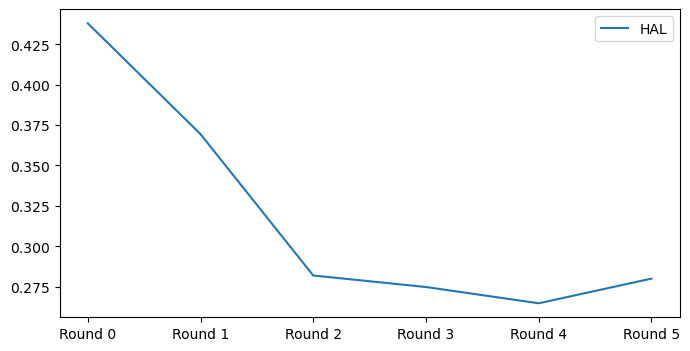

In [29]:
HAL_test_mae = [day0_mae, HAL_day1_mae, HAL_day2_mae, HAL_day3_mae, HAL_day4_mae, HAL_day5_mae]
xx = ['Round 0', 'Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5']
x = [i for i in range(6)]
plt.figure(figsize = (8,4))
plt.plot(x, HAL_test_mae, label = 'HAL')
plt.xticks(x, xx)
plt.legend()
# plt.savefig('plot/Experiment_mae.png', bbox_inches='tight', dpi = 300)

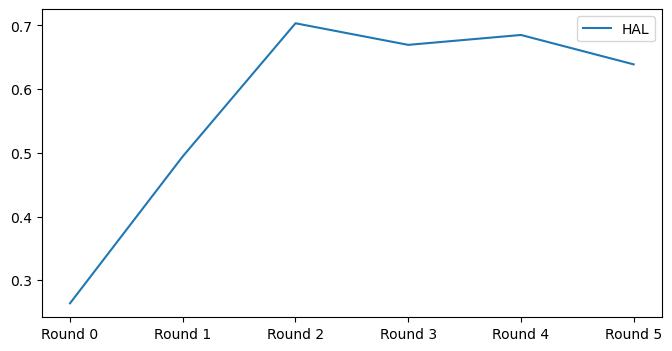

In [30]:
HAL_test_r2 = [day0_r2, HAL_day1_r2, HAL_day2_r2, HAL_day3_r2, HAL_day4_r2, HAL_day5_r2]
xx = ['Round 0', 'Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5']
x = [i for i in range(6)]
plt.figure(figsize = (8,4))
plt.plot(x, HAL_test_r2, label = 'HAL')
plt.xticks(x, xx)
plt.legend()
# plt.savefig('plot/Experiment_r2.png', bbox_inches='tight', dpi = 300)

In [31]:
importance_total = []
shap_values_total = []
for p in HAL_day5_params_list:
    model_for_importance = XGBRegressor(**p)
    model_for_importance.fit(scaled_HAL_day5_X_train, HAL_day5_y_train)
    pred_tmp = model_for_importance.predict(scaled_X_test)
    r2_tmp = r2_score(random_label_processed, pred_tmp)
    if r2_tmp >= 0.6:
        print(r2_tmp)   
        explainer = shap.Explainer(model_for_importance)
        shap_values = explainer(pd.DataFrame(scaled_HAL_day5_X_train, columns = lycopene_processed_onehot.columns.tolist()))
        shap_values_total.append(shap_values.values)
        importance = model_for_importance.feature_importances_
        importance_total.append(importance)


0.6548054425972265
0.6347614091632339
0.6306270769589797
0.6203760201419113
0.6465383730291907
0.6545226356794659
0.6029232594508268
0.631340907177597


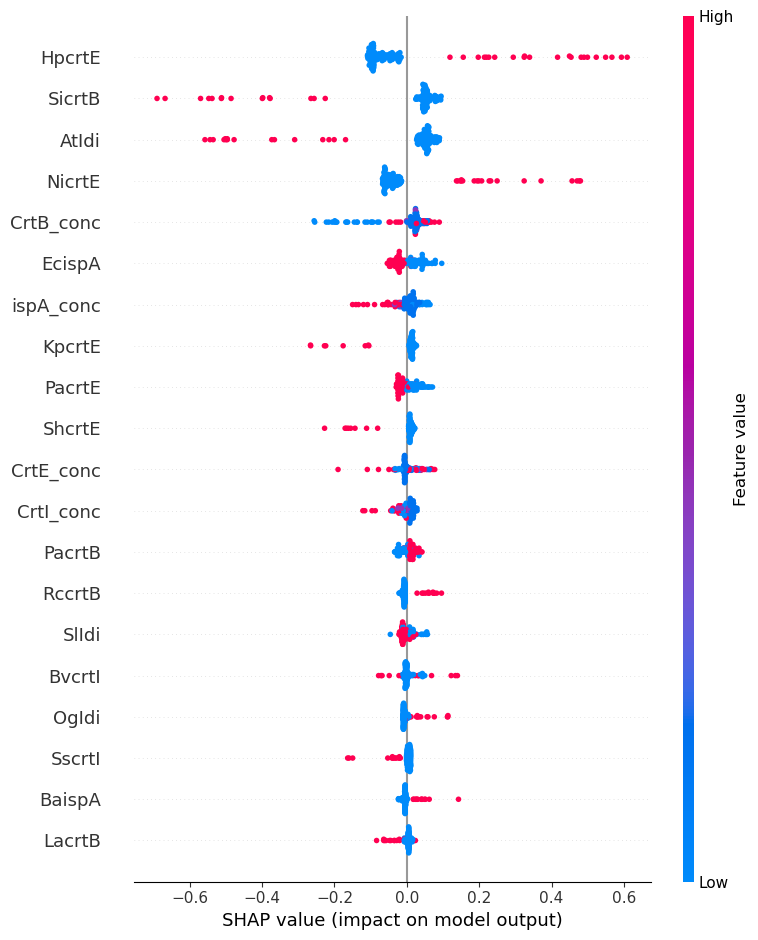

In [32]:
mean_shap_values = np.mean(shap_values_total, axis=0)
plt.figure(figsize = (8,6))
shap.summary_plot(mean_shap_values, scaled_HAL_day5_X_train, feature_names = col_list_total)
#plt.savefig("plot/Experiment_shap_summary.png", bbox_inches='tight')
plt.close()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SicrtB vs. not SicrtB: t-test independent samples, P_val:1.269e-04 t=-3.956e+00
AtIdi vs. not AtIdi: t-test independent samples, P_val:5.559e-04 t=-3.544e+00
NicrtE vs. not NicrtE: t-test independent samples, P_val:2.787e-02 t=2.225e+00
HpcrtE vs. not HpcrtE: t-test independent samples, P_val:9.106e-05 t=4.045e+00


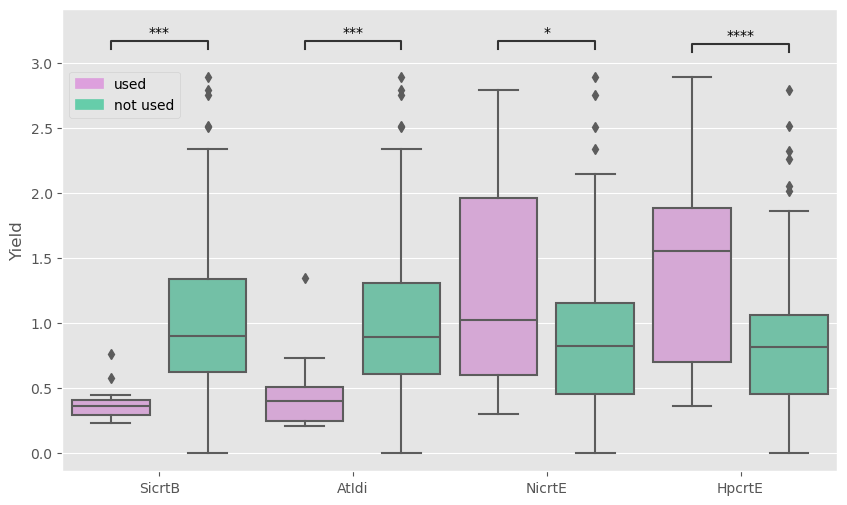

In [33]:
import matplotlib.patches as mpatches

sicrtb_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['SicrtB'] == 1].index.tolist()]
sicrtb_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['SicrtB'] != 1].index.tolist()]
atldi_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['AtIdi'] == 1].index.tolist()]
atldi_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['AtIdi'] != 1].index.tolist()]
nicrte_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['NicrtE'] == 1].index.tolist()]
nicrte_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['NicrtE'] != 1].index.tolist()]
hpcrte_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['HpcrtE'] == 1].index.tolist()]
hpcrte_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['HpcrtE'] != 1].index.tolist()]


data = pd.DataFrame({
    'Group': ['SicrtB']*len(sicrtb_pos) + ['not SicrtB']*len(sicrtb_neg) + ['AtIdi']*len(atldi_pos) + ['not AtIdi']*len(atldi_neg) + 
    ['NicrtE']*len(nicrte_pos) + ['not NicrtE']*len(nicrte_neg) + ['HpcrtE']*len(hpcrte_pos) + ['not HpcrtE']*len(hpcrte_neg),
    'Yield': np.concatenate([sicrtb_pos, sicrtb_neg, atldi_pos, atldi_neg, nicrte_pos, nicrte_neg , hpcrte_pos, hpcrte_neg]),
    'Pair' : ['SicrtB']*len(HAL_day5_y_train) + ['AtIdi']*len(HAL_day5_y_train) + ['NicrtE']*len(HAL_day5_y_train) + ['HpcrtE']*len(HAL_day5_y_train)
})

plt.figure(figsize = (10,6))
plt.style.use('ggplot')
# generate box plot
my_pal = {"SicrtB": "#DDA0DD", "not SicrtB": "#66CDAA", "AtIdi": "#DDA0DD", "not AtIdi": "#66CDAA",
         "NicrtE": "#DDA0DD", "not NicrtE": "#66CDAA", "HpcrtE": "#DDA0DD", "not HpcrtE": "#66CDAA"}
ax = sns.boxplot(x="Group", y="Yield", data=data, palette = my_pal)
ax.set_xlabel('')
legend_handles = [
    mpatches.Patch(color='#DDA0DD', label='used'),mpatches.Patch(color='#66CDAA', label='not used')]
plt.legend(handles=legend_handles, bbox_to_anchor=(0, 0.88), loc='upper left')
plt.xticks(ticks=[0.5, 2.5, 4.5, 6.5], labels=['SicrtB', 'AtIdi',"NicrtE", "HpcrtE" ])

pairs = [("SicrtB", "not SicrtB"), ("AtIdi", "not AtIdi"), ("NicrtE", "not NicrtE"), ("HpcrtE", "not HpcrtE")]
annotator = Annotator(ax, pairs, data=data, x="Group", y="Yield")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.savefig('plot/Experiment_important_enzyme.png', bbox_inches='tight', dpi = 300)
plt.show()

In [34]:
shap.initjs() 
shap.plots.force(shap_values)

Text(0, 0.5, 'Feature')

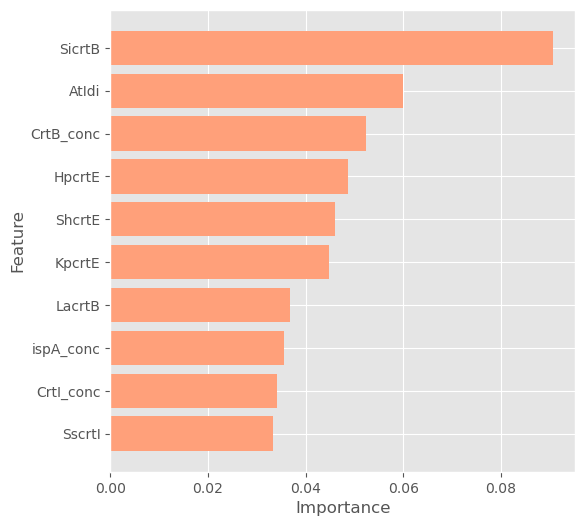

In [35]:
importance_mean = np.mean(importance_total, axis = 0)
importance_df = pd.DataFrame({'Feature': col_list_total, 'Importance': importance_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(6, 6))
plt.style.use('ggplot')
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1], color = '#FFA07A')
plt.xlabel('Importance')
plt.ylabel('Feature')
#plt.title('Feature Importance')
#plt.savefig('plot/Experiment_importance.png', bbox_inches='tight', dpi = 300)

In [37]:
importance_df.tail(4)

,Feature,Importance
8,BaispA,0.024290
5,KaispA,0.023800
6,JcispA,0.019430
2,RcIdi,0.015641


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

RcIdi vs. not RcIdi: t-test independent samples, P_val:5.355e-01 t=6.214e-01
JcispA vs. not JcispA: t-test independent samples, P_val:8.269e-01 t=2.192e-01
BaispA vs. not BaispA: t-test independent samples, P_val:5.350e-01 t=6.221e-01
KaispA vs. not KaispA: t-test independent samples, P_val:7.232e-01 t=3.550e-01


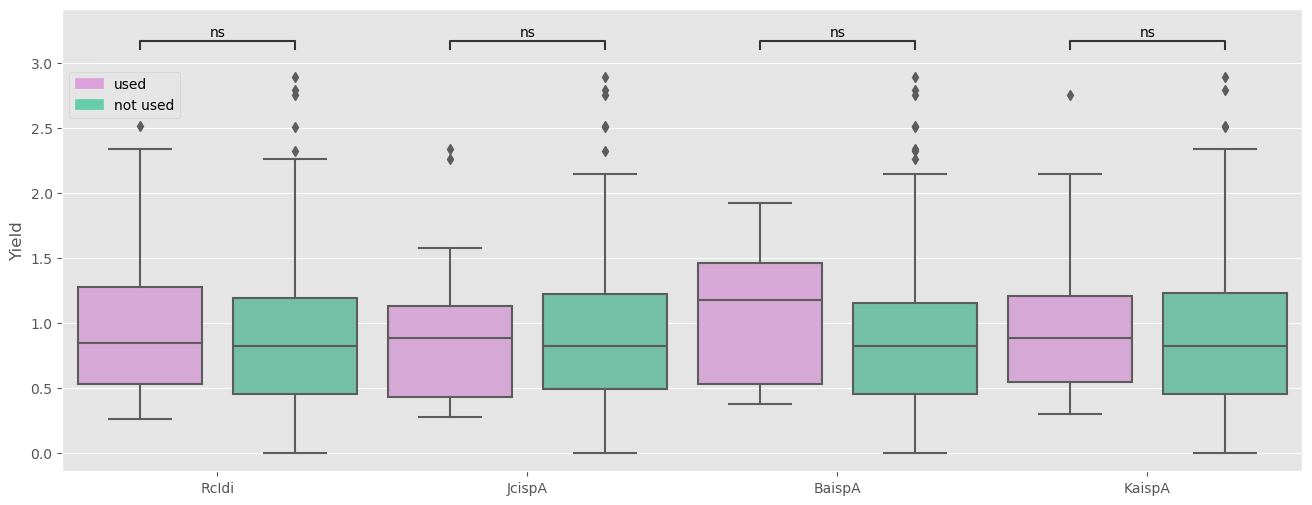

In [38]:
rcidi_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['RcIdi'] == 1].index.tolist()]
rcidi_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['RcIdi'] != 1].index.tolist()]
jcispa_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['JcispA'] == 1].index.tolist()]
jcispa_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['JcispA'] != 1].index.tolist()]
baispa_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['BaispA'] == 1].index.tolist()]
baispa_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['BaispA'] != 1].index.tolist()]
kaispa_pos = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['KaispA'] == 1].index.tolist()]
kaispa_neg = HAL_day5_y_train[HAL_day5_X_train.loc[HAL_day5_X_train['KaispA'] != 1].index.tolist()]


data = pd.DataFrame({
    'Group': ['RcIdi']*len(rcidi_pos) + ['not RcIdi']*len(rcidi_neg) + ['JcispA']*len(jcispa_pos) + ['not JcispA']*len(jcispa_neg) + 
    ['BaispA']*len(baispa_pos) + ['not BaispA']*len(baispa_neg) + ['KaispA']*len(kaispa_pos) + ['not KaispA']*len(kaispa_neg),
    'Yield': np.concatenate([rcidi_pos, rcidi_neg, jcispa_pos, jcispa_neg, baispa_pos, baispa_neg , kaispa_pos, kaispa_neg]),
    'Pair' : ['RcIdi']*len(HAL_day5_y_train) + ['JcispA']*len(HAL_day5_y_train) + ['BaispA']*len(HAL_day5_y_train) + ['KaispA']*len(HAL_day5_y_train)
})

plt.figure(figsize = (16,6))
# generate boxplot
my_pal = {"RcIdi": "#DDA0DD", "not RcIdi": "#66CDAA", "JcispA": "#DDA0DD", "not JcispA": "#66CDAA",
         "BaispA": "#DDA0DD", "not BaispA": "#66CDAA", "KaispA": "#DDA0DD", "not KaispA": "#66CDAA"}
ax = sns.boxplot(x="Group", y="Yield", data=data, palette = my_pal)
ax.set_xlabel('')
legend_handles = [
    mpatches.Patch(color='#DDA0DD', label='used'),mpatches.Patch(color='#66CDAA', label='not used')]

plt.legend(handles=legend_handles, bbox_to_anchor=(0, 0.88), loc='upper left')
plt.xticks(ticks=[0.5, 2.5, 4.5, 6.5], labels=['RcIdi', 'JcispA',"BaispA", "KaispA" ])

pairs = [("RcIdi", "not RcIdi"), ("JcispA", "not JcispA"), ("BaispA", "not BaispA"), ("KaispA", "not KaispA")]
annotator = Annotator(ax, pairs, data=data, x="Group", y="Yield")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.savefig('plot/Experiment_not_important_enzyme.png', bbox_inches='tight', dpi = 300)
plt.show()